In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], add_soap=True)
df = qm9.load()

2026-04-21 15:21:55.604 | INFO     | src.datasets:load:500 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-21 15:21:55.795 | INFO     | src.datasets:_sample_qm9_df:692 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-21 15:21:55.795 | INFO     | src.datasets:_add_requested_descriptors:129 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-21 15:21:55.795 | INFO     | src.features:compute_soap:170 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-21 15:22:35.553 | SUCCESS  | src.datasets:add_soap:846 - Added SOAP embeddings.
2026-04-21 15:22:35.554 | INFO     | src.datasets:_add_requested_descriptors:152 - Added descriptor column(s): ['soap_embedding']
2026-04-21 15:22:35.590 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:585 - Dropped QM9 rows with null/empty descriptor vectors: dropped=23, remaining=5477, descriptor_cols=['soap_embedding'].
2026-04-21 1

In [4]:
molecules = qm9.get_molecules()
len(molecules[0:2])

2026-04-21 10:13:16.215 | SUCCESS  | src.datasets:get_molecules:1181 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


2

In [6]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
dist_matrix = qm9.get_distance_matrix(
    descriptor="soap",
    dist_type="soap_kernel",
    force_calculate=True,
    pca_variance=90
)

2026-04-21 15:24:04.770 | INFO     | src.datasets:get_distance_matrix:995 - Applying PCA to retain 90.00% of variance.
2026-04-21 15:24:07.592 | INFO     | src.datasets:get_distance_matrix:1005 - PCA reduced 'soap' dimensions from 2240 to 5
2026-04-21 15:24:07.606 | INFO     | src.datasets:get_distance_matrix:1016 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-21 15:24:07.885 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_soap_soap_kernel_pca0.9.npy


# Determining the best number of clusters for each clustering method

In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    dataset_name="qm9",
)

Evaluation k:   0%|          | 0/19 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [10]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1332), np.int64(1333)), (np.int64(1176), np.int64(1180)), (np.int64(3300), np.int64(3313)), (np.int64(1002), np.int64(1004)), (np.int64(2949), np.int64(3851)), (np.int64(1236), np.int64(1238)), (np.int64(2567), np.int64(2642)), (np.int64(421), np.int64(474)), (np.int64(3587), np.int64(4743)), (np.int64(3070), np.int64(4550))]


In [11]:
print(mols[0])

(Atoms(symbols='H3CH3NHOCNCNC2', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H3CH3NHOCNCNC2', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [12]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [35.0, 35.0, 45.0, 45.0],
  [25.0, 25.0, 40.0, 40.0],
  [10.0, 10.0, 32.5, 32.5],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [62.5, 62.5, 92.5, 92.5],
  [21.25, 21.25, 77.5, 77.5],
  [125.0, 125.0, 135.0, 135.0],
  [115.0, 115.0, 130.0, 130.0],
  [155.0, 155.0, 165.0, 165.0],
  [145.0, 145.0, 160.0, 160.0],
  [122.5, 122.5, 152.5, 152.5],
  [185.0, 185.0, 195.0, 195.0],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [190.0, 190.0, 212.5, 212.5],
  [175.0, 175.0, 201.25, 201.25],
  [255.0, 255.0, 265.0, 265.0],
  [245.0, 245.0, 260.0, 260.0],
  [235.0, 235.0, 252.5, 252.5],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [243.75, 243.75, 282.5, 282.5],
  [188.125, 188.125, 263.125, 263.125],
  [137.5, 137.5, 225.625, 225.625],
  [49.375, 49.375, 181.5625, 181.5625]],
 'dcoord': [[0.0,
   np.float64(1.575463891029358),
   np.float64(1.57546

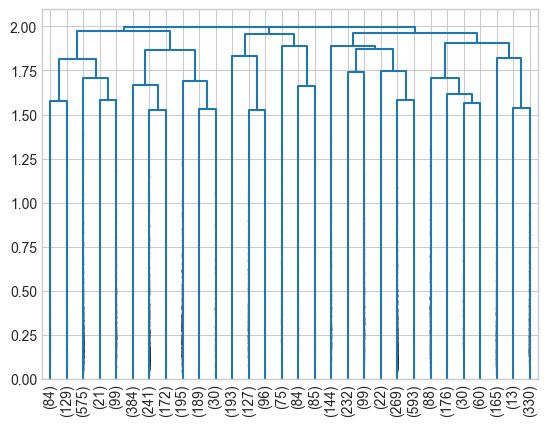

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show the last 30 merges
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

In [12]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=2, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1]), array([3208, 1792]))


In [30]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-21 10:27:54.189 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_hierarchical_projection.png


{'coords': array([[ -9.232232 ,   8.259477 ],
        [-27.138084 ,  -2.3655672],
        [-28.858639 ,   7.980999 ],
        ...,
        [-20.238884 ,  -4.62918  ],
        [ -8.685661 ,  21.430172 ],
        [-17.144505 ,  12.722071 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'hierarchical'}

In [13]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (2, 62)
┌─────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┬──────────────────┬──────────────┬──────────────────┐
│ labels_hier ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinit

# KMedoids

In [43]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)
print(np.unique(labels_km, return_counts=True))

(array([0, 1, 2], dtype=uint64), array([1640, 1777, 1583]))


In [34]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [42]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-21 10:33:33.847 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_kmedoids_projection.png


{'coords': array([[ -9.232232 ,   8.259477 ],
        [-27.138084 ,  -2.3655672],
        [-28.858639 ,   7.980999 ],
        ...,
        [-20.238884 ,  -4.62918  ],
        [ -8.685661 ,  21.430172 ],
        [-17.144505 ,  12.722071 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'kmedoids'}

In [37]:
average_numeric_by_cluster(df, "labels_km")

shape: (3, 60)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_km ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆

labels_km,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1640,2.027751,16.837805,120.415854,-0.181098,47.4,0.72758,12.93634,8.62622,1.129878,0.296341,2.011134,2.44878,0.109628,0.32932,0.561052,1.284756,2.239024,6.127439,0.668902,1.717073,3.258537,6.577439,34.486585,1.252984,0.00122,0.172561,0.059756,0.338415,0.27622,0.003049,0.021341,0.070732,0.290854,0.00061,2.981707,3.13057,73.817848,-6.408794,0.007661,6.41643,1230.809968,3.707795,-11060.319889,-11060.085545,-11060.059849,-11061.239575,31.165643,-71.512243,-71.926848,-72.333901,-66.599885,3.950534,1.335816,1.041487,0.459146,52.804878,28.231707,18.963415
1,1777,2.069,17.975239,125.34834,-0.09623,40.592009,0.974922,12.822673,8.83399,1.661227,0.032077,2.064212,2.578503,0.040704,0.161701,0.797595,0.895892,2.519415,6.093979,0.253236,0.945414,4.940912,6.241418,37.335959,1.26645,0.001125,0.679235,0.010692,0.051773,0.069218,0.001688,0.091728,0.202589,1.002814,0.0,2.694429,2.656861,71.945065,-6.719338,0.276879,6.99622,1165.517297,4.014762,-11824.139474,-11823.905625,-11823.879929,-11825.05244,31.912555,-75.529546,-75.988484,-76.42478,-70.265218,3.112627,1.415106,1.146115,0.0,86.550366,3.207653,10.241981
2,1583,2.207673,19.979785,121.696147,0.56475,18.146557,0.917297,12.745489,8.842072,2.255843,0.019583,2.112036,1.887555,0.057869,0.109623,0.832507,0.550221,1.022742,7.457991,0.442198,0.822489,6.284902,6.195831,44.168035,1.26688,0.001895,0.208465,0.001895,0.020846,0.032849,0.0,0.005054,0.104232,0.345546,0.0,1.292483,2.093577,80.850853,-6.475125,0.87143,7.346576,1161.125104,4.678947,-10371.544798,-10371.315591,-10371.289907,-10372.442861,32.580867,-83.8816,-84.422454,-84.910296,-78.035654,3.089502,1.4592,1.203384,0.862919,94.946304,1.895136,3.15856


# Spectral

In [ ]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

In [50]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [48]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-21 10:56:13.228 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_spectral_projection.png


{'coords': array([[ -9.232232 ,   8.259477 ],
        [-27.138084 ,  -2.3655672],
        [-28.858639 ,   7.980999 ],
        ...,
        [-20.238884 ,  -4.62918  ],
        [ -8.685661 ,  21.430172 ],
        [-17.144505 ,  12.722071 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'spectral'}

In [49]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 61)
┌─────────────────┬───────┬─────────────────────┬───────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_spectral ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp   ┆ tpsa    ┆ election_affinity ┆ ionization_energ

labels_spectral,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4998,2.099514,18.237695,122.573229,0.085234,35.704282,0.875679,12.835435,8.768307,1.67547,0.114446,2.061968,2.316927,0.068773,0.199952,0.731275,0.913565,1.952781,6.537015,0.44958,1.158463,4.816126,6.336535,38.568627,1.262176,0.001401,0.363745,0.02401,0.135654,0.12565,0.001601,0.041216,0.128251,0.561425,0.0002,2.344138,2.634447,75.378173,-6.540442,0.377312,6.917753,1185.496267,4.124637,-11113.435414,-11113.20287,-11113.177177,-11114.345865,31.879587,-76.858989,-77.329352,-77.772399,-71.525726,3.379526,1.403213,1.130041,0.423569,0.988996,78.171269,10.964386,10.864346
1,1,1.75,16.0,125.0,0.0,72.0,0.553192,13.044433,9.0,1.0,1.0,2.0,3.0,0.0,0.8,0.2,2.0,4.0,6.0,0.0,4.0,1.0,8.0,28.0,1.246962,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.2696,77.220001,-5.839563,-0.876207,4.963357,1301.641846,3.424907,-11812.84082,-11812.614258,-11812.587891,-11813.75293,30.801001,-69.714729,-70.104431,-70.489929,-64.984146,4.91343,1.01771,0.84807,1.0,0.0,0.0,100.0,0.0
2,1,1.75,16.0,125.0,0.0,72.0,0.553192,13.044433,9.0,1.0,1.0,2.0,3.0,0.0,0.8,0.2,2.0,4.0,6.0,0.0,4.0,1.0,8.0,28.0,1.246962,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.2709,77.220001,-5.839563,-0.876207,4.963357,1301.641357,3.424907,-11812.84082,-11812.614258,-11812.587891,-11813.75293,30.801001,-69.714729,-70.104431,-70.489929,-64.984116,4.91342,1.01771,0.84807,1.0,0.0,0.0,100.0,0.0


# DBSCAN 

In [56]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=3,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7]), array([ 122, 4848,    3,    5,    8,    4,    3,    4,    3]))


In [57]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [58]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric="soap_kernel",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-21 10:59:59.764 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/soap_kernel/soap/pca_dbscan_projection.png


{'coords': array([[ -9.232232 ,   8.259477 ],
        [-27.138084 ,  -2.3655672],
        [-28.858639 ,   7.980999 ],
        ...,
        [-20.238884 ,  -4.62918  ],
        [ -8.685661 ,  21.430172 ],
        [-17.144505 ,  12.722071 ]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/qm9/clustering/soap_kernel/soap/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/soap_kernel/soap'),
 'clustering_method': 'dbscan'}

In [60]:
d =average_numeric_by_cluster(df, "labels_db")

shape: (9, 62)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬────────────────────┬──────────────┬─────────────┐
│ labels_db ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionizati

# KMeans

In [71]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = np.array(df['soap_embedding'].to_list())
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X_pca)
df = df.with_columns(labels_kmeans=labels_kmeans)

print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([1724, 1993, 1283]))


In [72]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [73]:
average_numeric_by_cluster(df, 'labels_kmeans')

shape: (3, 63)
┌───────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_kmeans ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election

labels_kmeans,count,token_to_atom_ratio,num_atoms,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_spectral,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1724,2.046687,17.653712,124.694896,-0.101508,42.810905,0.95808,12.840825,8.776102,1.424014,0.057425,2.041544,2.765081,0.05465,0.189314,0.756036,0.939675,2.580626,5.904872,0.339907,1.077146,4.533643,6.388051,36.302784,1.263001,0.00116,0.62935,0.022622,0.080046,0.112529,0.00058,0.095708,0.193735,0.966357,0.0,2.825406,2.712815,71.458121,-6.731148,0.148403,6.879532,1199.027688,3.915515,-11821.269144,-11821.031702,-11821.005998,-11822.190222,31.935197,-74.218898,-74.661855,-75.089884,-69.06029,3.290696,1.36479,1.101403,0.00116,0.866589,0.0,-0.00232,80.510441,5.742459,13.7471
1,1993,2.196672,19.823382,122.459107,0.446061,20.755143,0.923891,12.753512,8.865529,2.242348,0.019568,2.112089,1.937782,0.053312,0.108062,0.838627,0.607627,1.199699,7.346713,0.401405,0.797792,6.212243,6.162067,43.606623,1.267566,0.001505,0.28299,0.001505,0.02559,0.035123,0.001505,0.010035,0.117913,0.423482,0.0,1.454089,2.198211,79.948404,-6.482989,0.842178,7.325173,1156.989046,4.623927,-10566.671445,-10566.442226,-10566.416536,-10567.56973,32.542494,-83.206462,-83.741265,-84.225084,-77.401841,3.04911,1.461975,1.204697,0.713497,1.730557,0.0,0.006021,94.831912,1.906673,3.261415
2,1283,2.01903,16.555729,119.903352,-0.224474,49.433359,0.68956,12.955778,8.607171,1.131723,0.339829,2.011459,2.304754,0.111661,0.357924,0.530415,1.355417,2.282151,6.127825,0.671083,1.832424,3.021044,6.54092,33.77085,1.252669,0.001559,0.133281,0.060795,0.382697,0.28371,0.003118,0.016368,0.056118,0.230709,0.000779,3.082619,3.204661,73.549166,-6.37234,-0.039171,6.333184,1211.777647,3.628958,-11012.729296,-11012.498176,-11012.472494,-11013.644367,30.773426,-70.535306,-70.942271,-71.342071,-65.700497,4.014544,1.362962,1.052114,0.541699,0.0,0.002338,-0.01325,49.025721,32.190179,18.7841
